# **3D Scene Reconstruction using NeRFs**

NeRF is a state-of-the-art technique used for 3D scene reconstruction that leverages neural networks to represent and render complex 3D environments from a collection of 2D images.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### **Import Required Libraries**

In [ ]:
# Import Required Libraries
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import plotly.graph_objs as go


!pip install open3d
import open3d as o3d

import os, sys
import tensorflow as tf
tf.compat.v1.enable_eager_execution()

from tqdm import tqdm_notebook as tqdm
import numpy as np
import matplotlib.pyplot as plt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 447.7/447.7 MB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 26.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.7/101.7 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 228.0/228.0 kB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 54.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 54.8 MB/s eta 0:00:00
  Attempting uninstall: widgetsnbextension
    Found existing installation: widgetsnbextension 3.6.10
    Uninstalling widgetsnbextension-3.6.10:
      Successfully uninstalled widgetsnbextension-3.6.10
  Attempting uninstall: werkzeug
    Found existing installation: Werkzeug 3.1.3
    Uninstalling Werkzeug-3.1.3:
      Successfully uninstalled Werkzeug-3.1.3
  Attempting uninstall: flask
    Found existing installation: Flask 3.1.0
    Unins

### **Load data**

The dataset of images and camera poses, essential for training the NeRF model, is loaded. This dataset includes images, poses (camera positions and orientations), and the focal length of the camera used for the scene capture.

In [ ]:
if not os.path.exists('tiny_nerf_data.npz'):
    !wget http://cseweb.ucsd.edu/~viscomp/projects/LF/papers/ECCV20/nerf/tiny_nerf_data.npz



--2025-01-31 00:33:26--  http://cseweb.ucsd.edu/~viscomp/projects/LF/papers/ECCV20/nerf/tiny_nerf_data.npz
Resolving cseweb.ucsd.edu (cseweb.ucsd.edu)... 132.239.8.30
Connecting to cseweb.ucsd.edu (cseweb.ucsd.edu)|132.239.8.30|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://cseweb.ucsd.edu//~viscomp/projects/LF/papers/ECCV20/nerf/tiny_nerf_data.npz [following]
--2025-01-31 00:33:26--  https://cseweb.ucsd.edu//~viscomp/projects/LF/papers/ECCV20/nerf/tiny_nerf_data.npz
Connecting to cseweb.ucsd.edu (cseweb.ucsd.edu)|132.239.8.30|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 12727482 (12M)
Saving to: ‘tiny_nerf_data.npz’

tiny_nerf_data.npz  100%[===================>]  12.14M  28.0MB/s    in 0.4s    

2025-01-31 00:33:27 (28.0 MB/s) - ‘tiny_nerf_data.npz’ saved [12727482/12727482]



In [ ]:
data = np.load('tiny_nerf_data.npz')
images = data['images']
poses = data['poses']
focal = data['focal']
H, W = images.shape[1:3]
print(images.shape, poses.shape, focal)

(106, 100, 100, 3) (106, 4, 4) 138.88887889922103


In [ ]:
print(poses.shape)

(106, 4, 4)


In [ ]:
print(len(images))

106


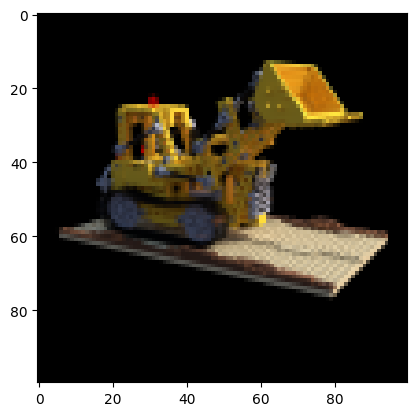

In [ ]:
testimg, testpose = images[10], poses[10]

plt.imshow(testimg)
plt.show()

### **Positional encoding**
The positional encoding function is utilized to encode the input coordinates (3D positions) into a higher-dimensional space to aid the neural network in learning more complex patterns. This is a crucial step in NeRF for representing 3D locations in a manner that the neural network can understand.

In [ ]:
def posenc(x):
  rets = [x]
  for i in range(L_embed):
    for fn in [tf.sin, tf.cos]:
      rets.append(fn(2.**i * x))
  return tf.concat(rets, -1)

L_embed = 4
embed_fn = posenc

#L_embed = 6
#embed_fn = posenc


# L_embed = 0
# embed_fn = tf.identity


### **NeRF Model**
The NeRF model is defined using a neural network with several layers. The model incorporates ReLU activations and skip connections at every fourth layer to enhance training efficiency.

In [ ]:
from tensorflow.keras.layers import Concatenate

def init_model(D=8, W=256):
    relu = tf.keras.layers.ReLU()
    dense = lambda W=W, act=relu: tf.keras.layers.Dense(W, activation=act)

    inputs = tf.keras.Input(shape=(3 + 3 * 2 * L_embed,))
    x = inputs
    for i in range(D):
        x = dense()(x)
        if i % 4 == 0 and i > 0:  # add a skip connection every 4 layers
            x = Concatenate()([x, inputs])
    outputs = dense(4, act=None)(x)

    model = tf.keras.Model(inputs=inputs, outputs=outputs)
    return model

### **Ray Generation and Volume Rendering**

This step generates rays from the camera to the scene. These rays are traced through the scene to gather information on how light interacts with the 3D scene, which will be rendered into an image.

In [ ]:
def get_rays(H, W, focal, c2w):
    i, j = tf.meshgrid(tf.range(W, dtype=tf.float32), tf.range(H, dtype=tf.float32), indexing='xy')
    dirs = tf.stack([(i-W*.5)/focal, -(j-H*.5)/focal, -tf.ones_like(i)], -1)
    rays_d = tf.reduce_sum(dirs[..., np.newaxis, :] * c2w[:3,:3], -1)
    rays_o = tf.broadcast_to(c2w[:3,-1], tf.shape(rays_d))
    return rays_o, rays_d



def render_rays(network_fn, rays_o, rays_d, near, far, N_samples, rand=False):

    def batchify(fn, chunk=1024*32):
        return lambda inputs : tf.concat([fn(inputs[i:i+chunk]) for i in range(0, inputs.shape[0], chunk)], 0)




    # Compute 3D query points
    z_vals = tf.linspace(near, far, N_samples)
    if rand:
      z_vals += tf.random.uniform(list(rays_o.shape[:-1]) + [N_samples]) * (far-near)/N_samples
    pts = rays_o[...,None,:] + rays_d[...,None,:] * z_vals[...,:,None]

    # Run network
    pts_flat = tf.reshape(pts, [-1,3])
    pts_flat = embed_fn(pts_flat)
    raw = batchify(network_fn)(pts_flat)
    raw = tf.reshape(raw, list(pts.shape[:-1]) + [4])

    # Compute opacities and colors
    sigma_a = tf.nn.relu(raw[...,3])
    rgb = tf.math.sigmoid(raw[...,:3])


    # Do volume rendering
    dists = tf.concat([z_vals[..., 1:] - z_vals[..., :-1], tf.broadcast_to([1e10], z_vals[...,:1].shape)], -1)
    alpha = 1.-tf.exp(-sigma_a * dists)
    weights = alpha * tf.math.cumprod(1.-alpha + 1e-10, -1, exclusive=True)

    rgb_map = tf.reduce_sum(weights[...,None] * rgb, -2)
    depth_map = tf.reduce_sum(weights * z_vals, -1)
    acc_map = tf.reduce_sum(weights, -1)

    return rgb_map, depth_map, acc_map

### **Model Training**
The training of the NeRF model involves optimizing the network's parameters to learn the radiance field that accurately represents the 3D scene. The model is trained by minimizing the loss function, which compares the predicted pixel colors of the rendered image with the corresponding ground truth values from the dataset.

0 0.22085983276367188 secs per iter


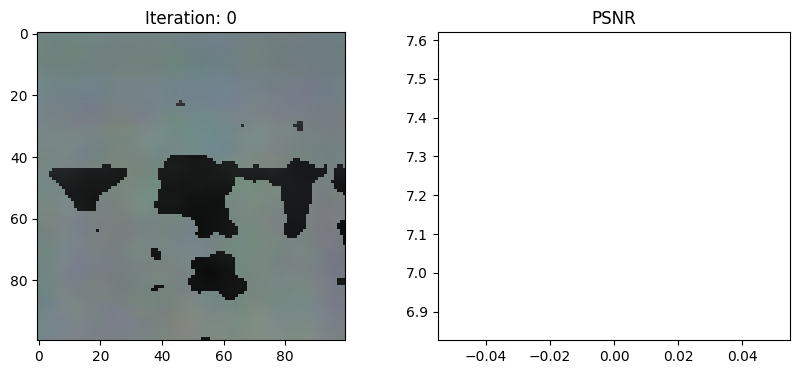

25 0.9084811878204345 secs per iter


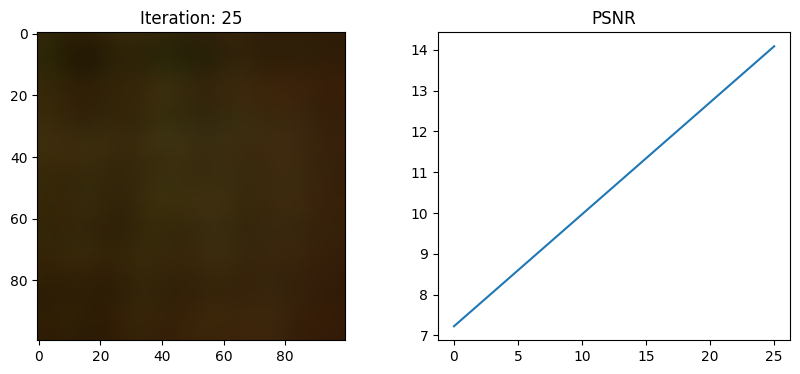

50 0.7273925685882568 secs per iter


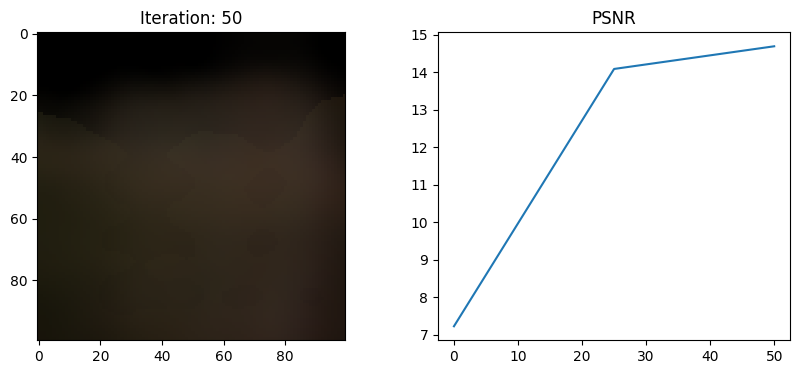

75 0.7275530433654785 secs per iter


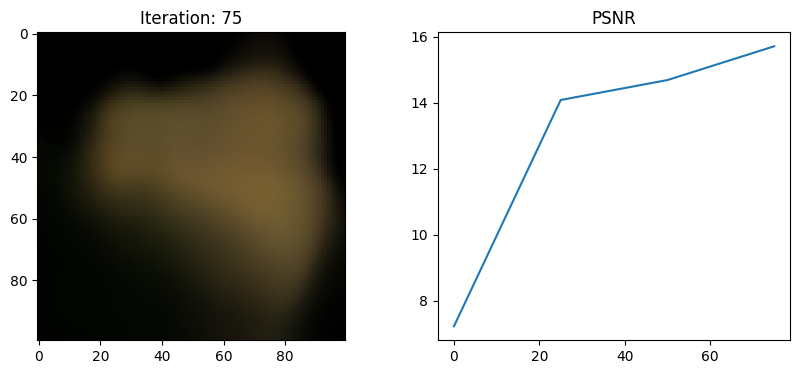

100 0.7574106216430664 secs per iter


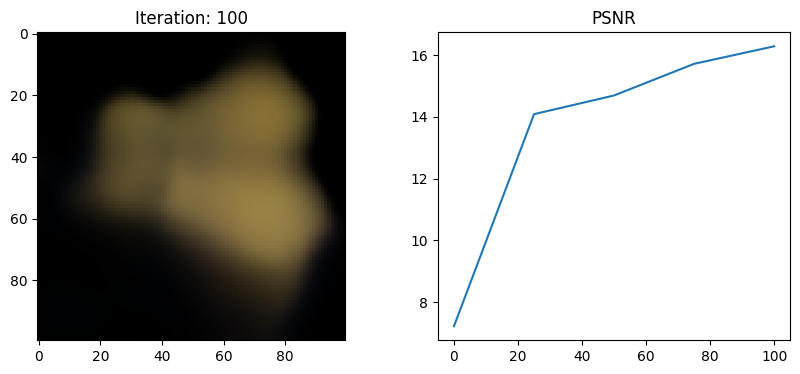

125 0.7337720203399658 secs per iter


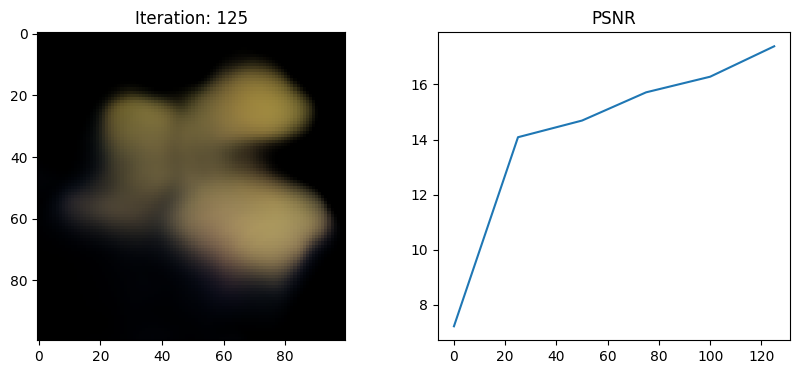

150 0.7610671138763427 secs per iter


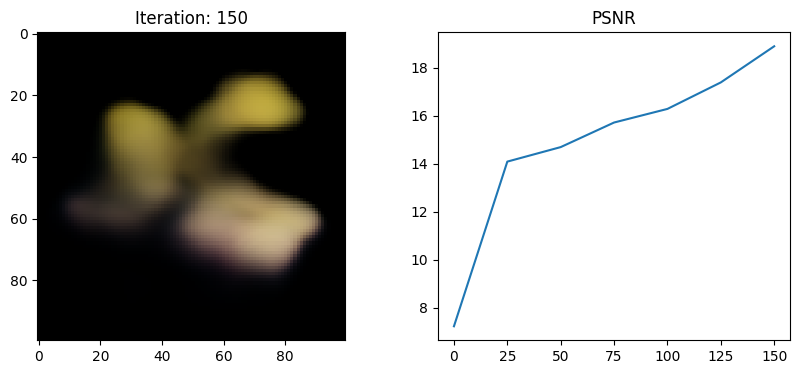

175 0.7096936702728271 secs per iter


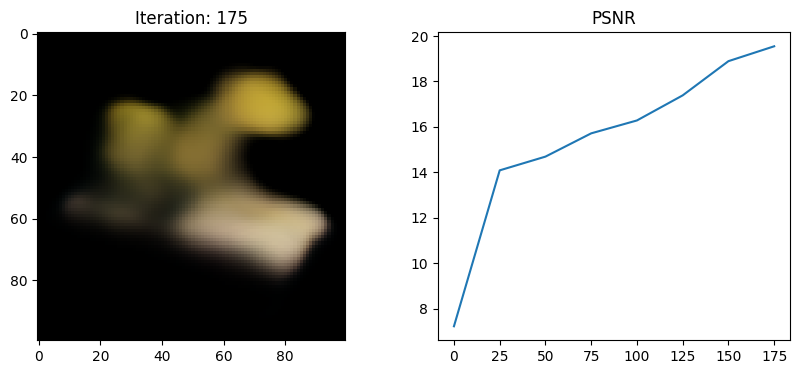

200 0.7284262943267822 secs per iter


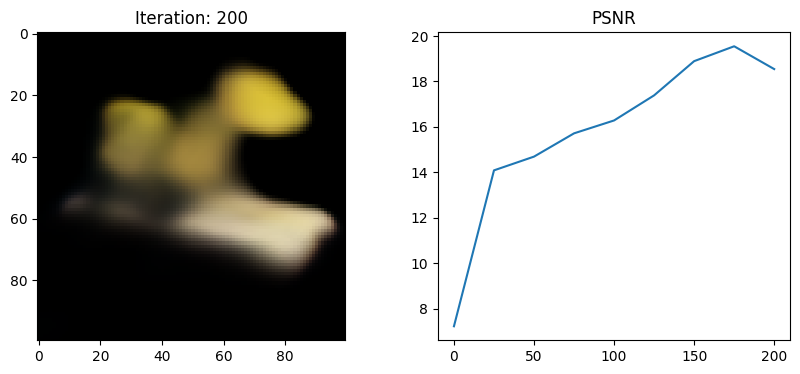

225 0.7415590286254883 secs per iter


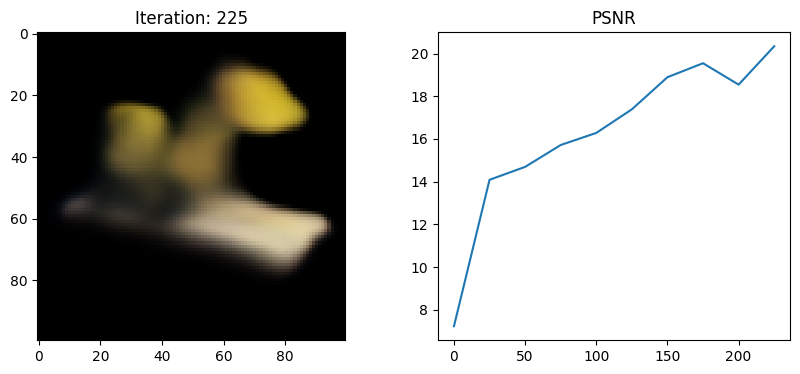

250 0.7183296585083008 secs per iter


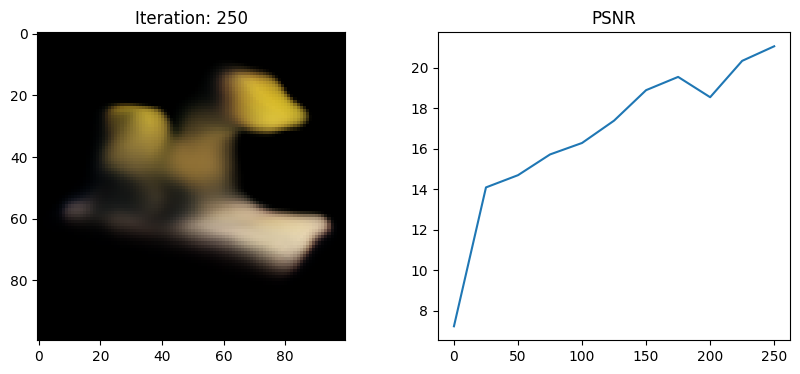

275 0.7125838088989258 secs per iter


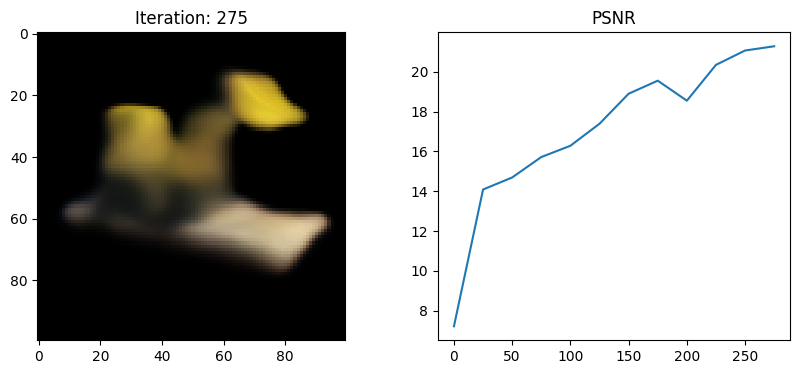

300 0.7294321727752685 secs per iter


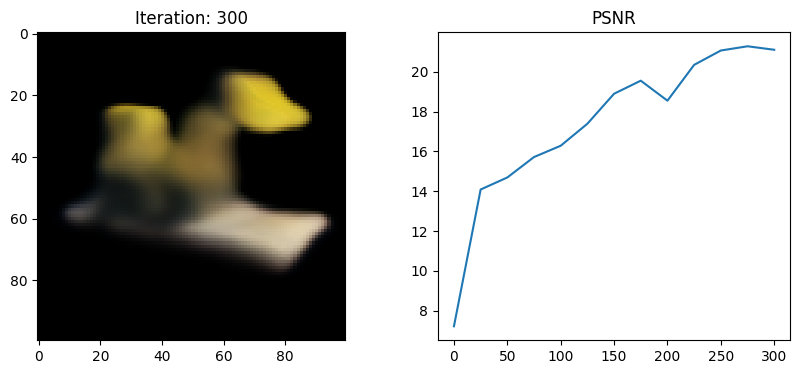

325 0.7143619728088378 secs per iter


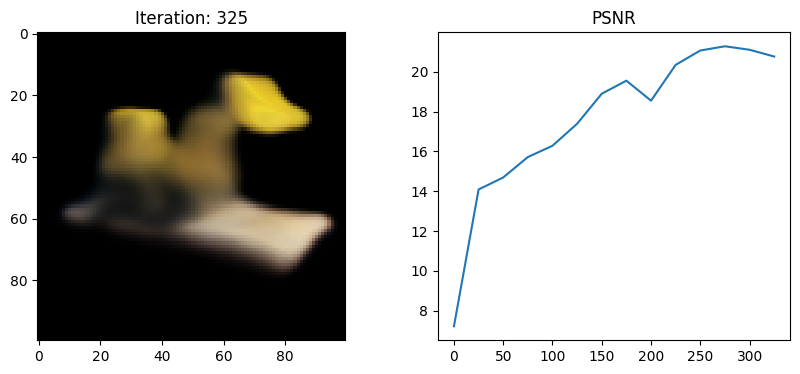

350 0.7166957473754882 secs per iter


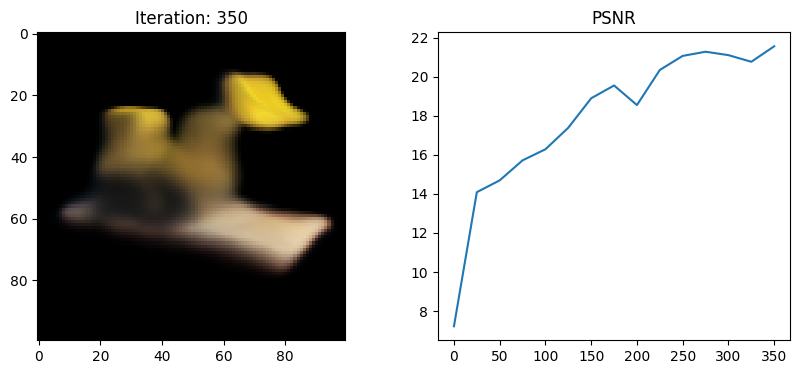

375 0.7317871856689453 secs per iter


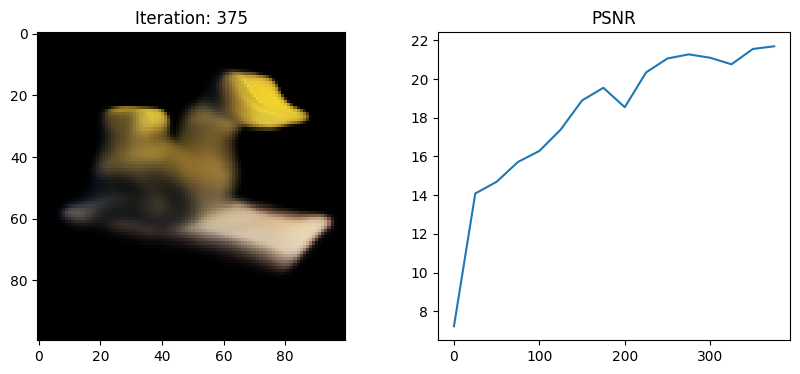

400 0.7110640621185302 secs per iter


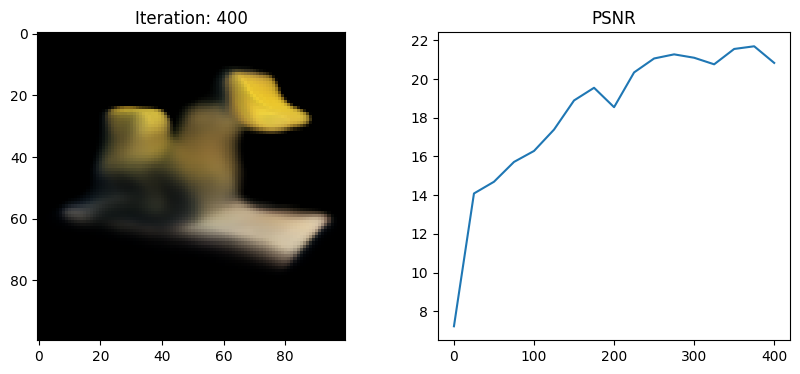

425 0.7146794033050538 secs per iter


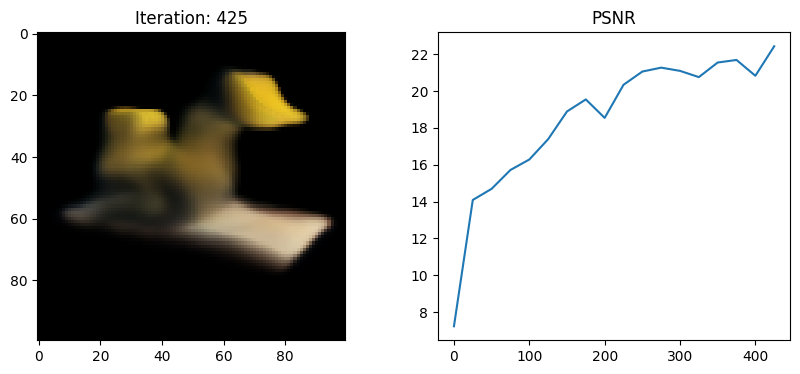

450 0.7295582675933838 secs per iter


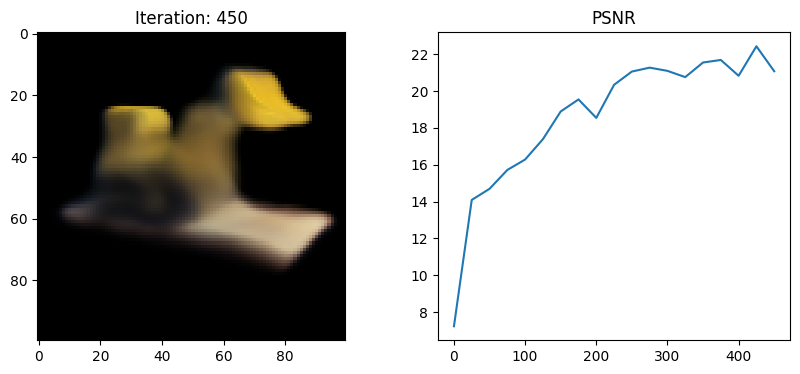

475 0.7094810962677002 secs per iter


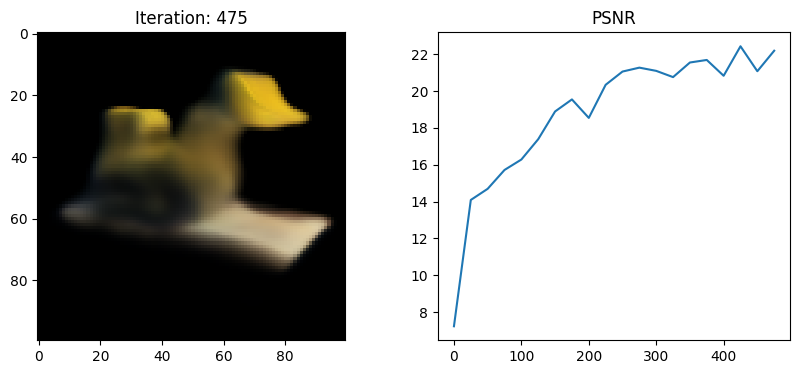

500 0.7231292915344238 secs per iter


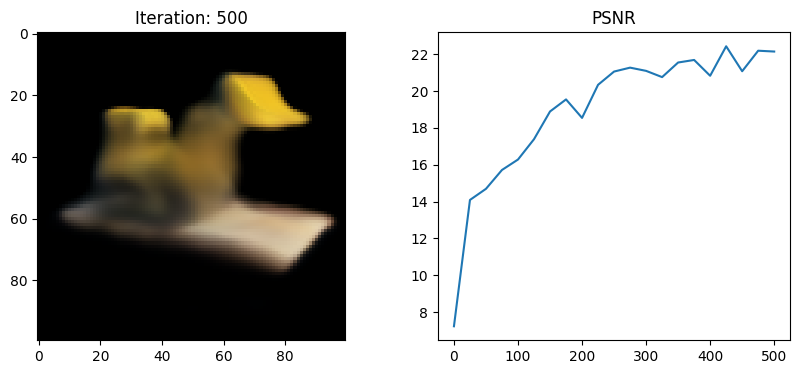

525 0.728358154296875 secs per iter


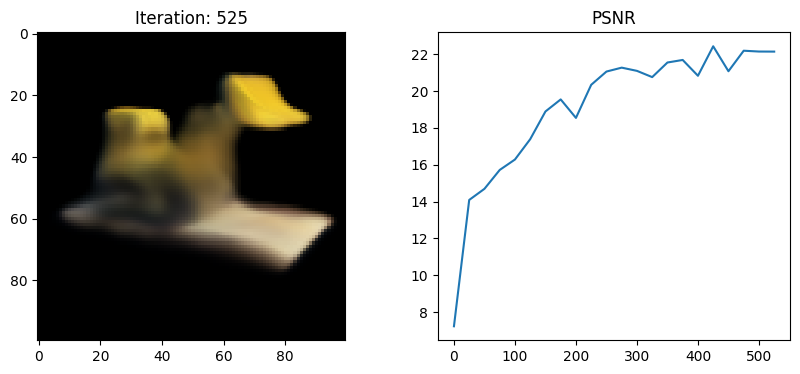

550 0.7109120845794678 secs per iter


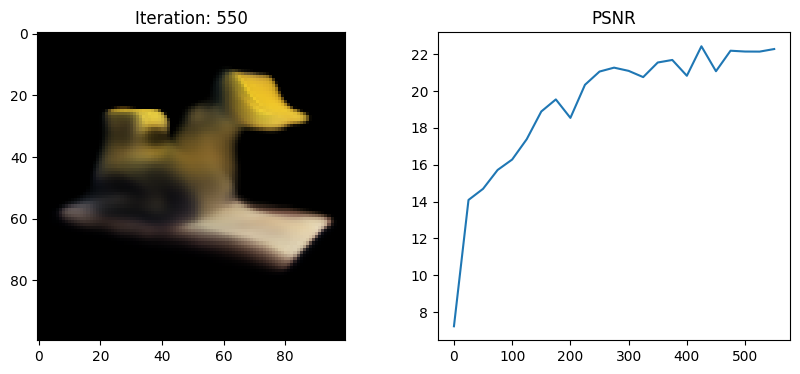

575 0.7123680591583252 secs per iter


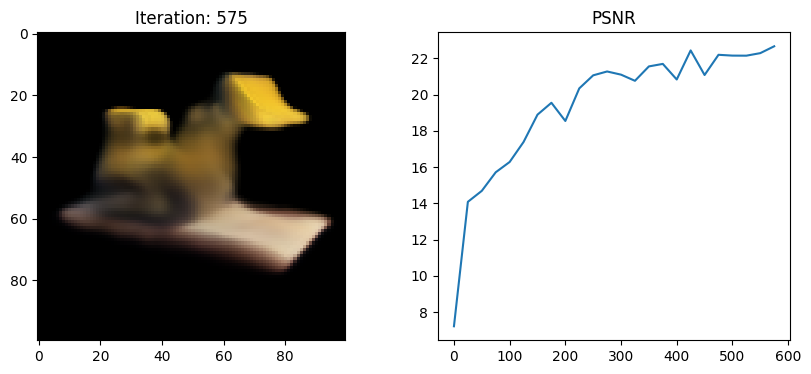

600 0.7229483890533447 secs per iter


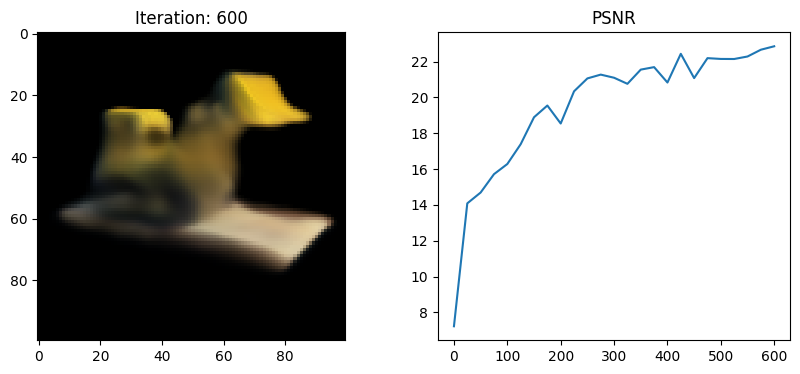

625 0.7164461517333984 secs per iter


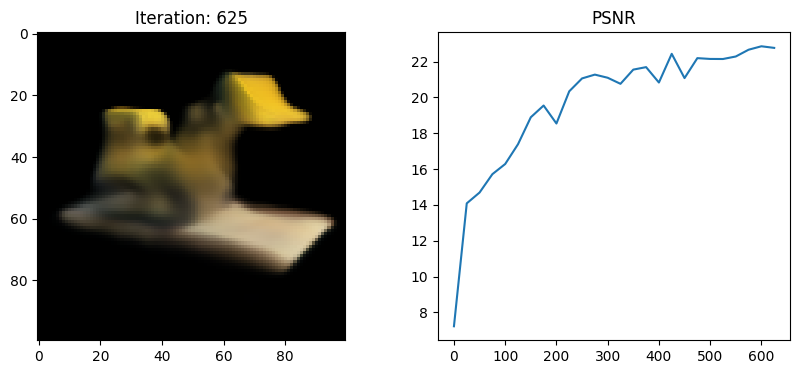

650 0.7098302364349365 secs per iter


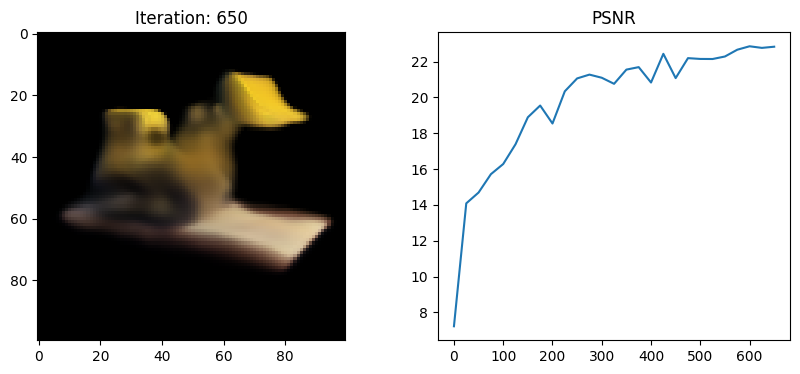

675 0.7220506000518799 secs per iter


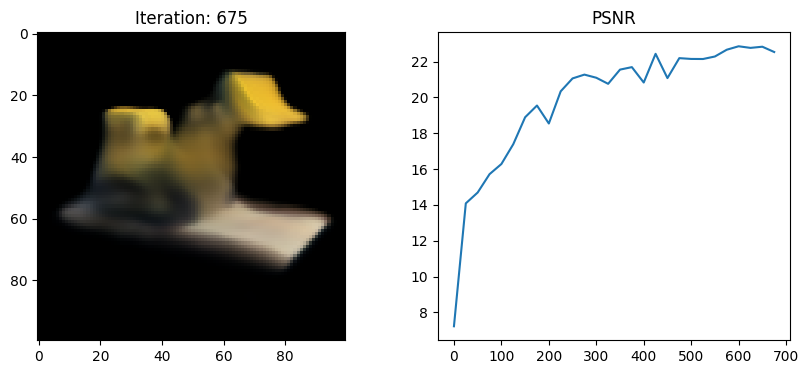

700 0.7187328338623047 secs per iter


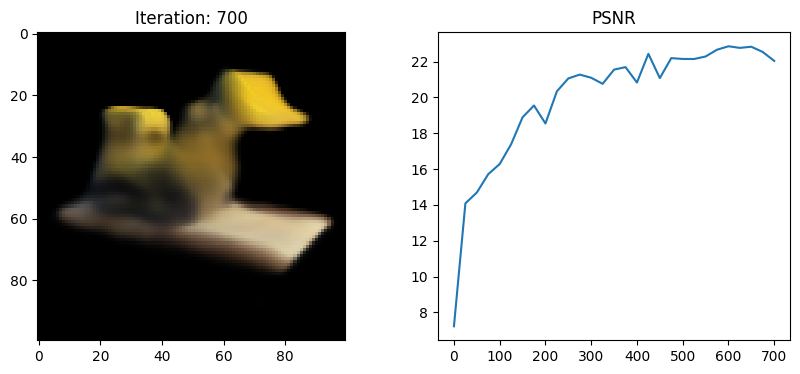

725 0.7104320049285888 secs per iter


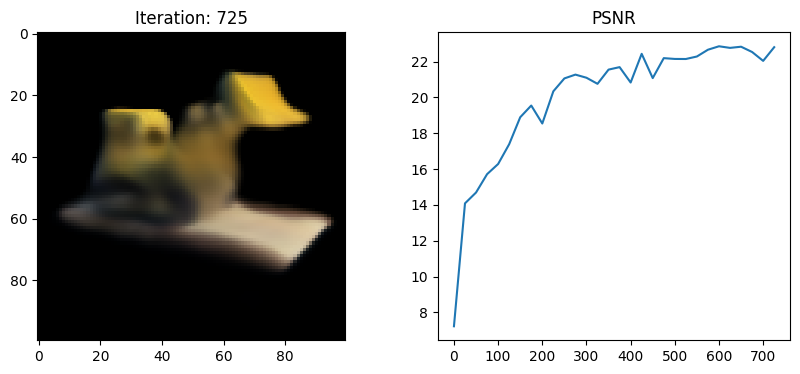

750 0.7170191383361817 secs per iter


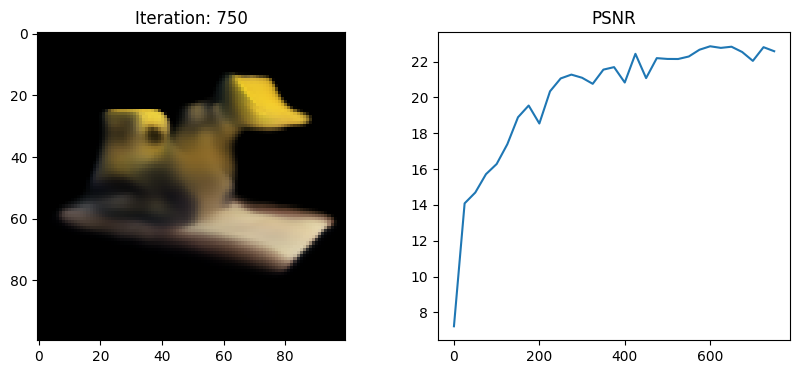

775 0.7269571399688721 secs per iter


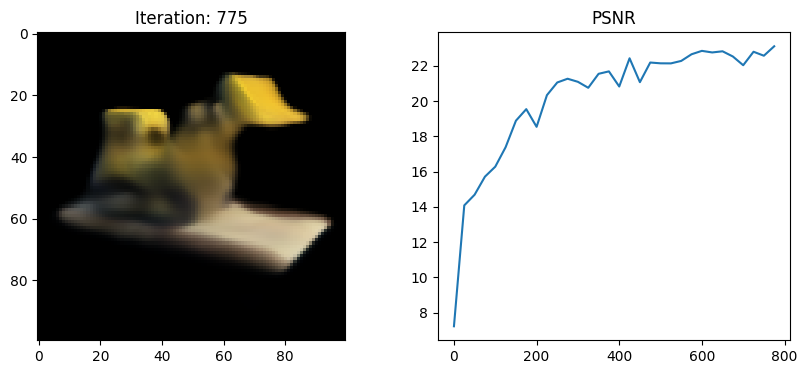

800 0.7077027702331543 secs per iter


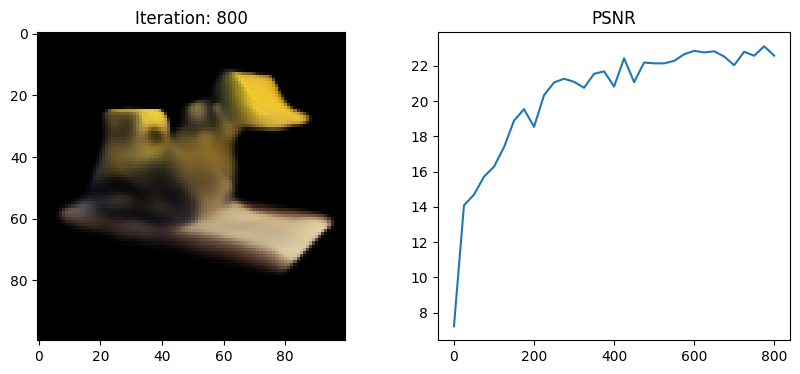

825 0.7131300067901611 secs per iter


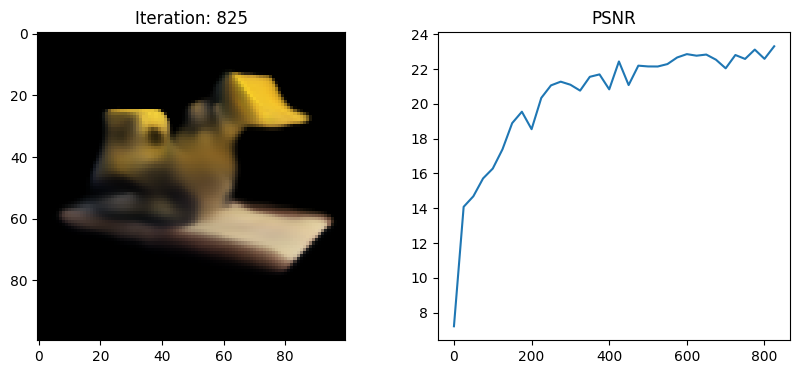

850 0.7170495796203613 secs per iter


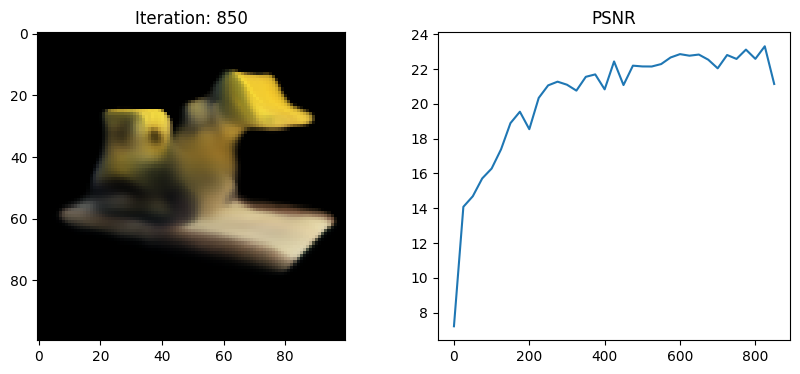

875 0.7100182628631592 secs per iter


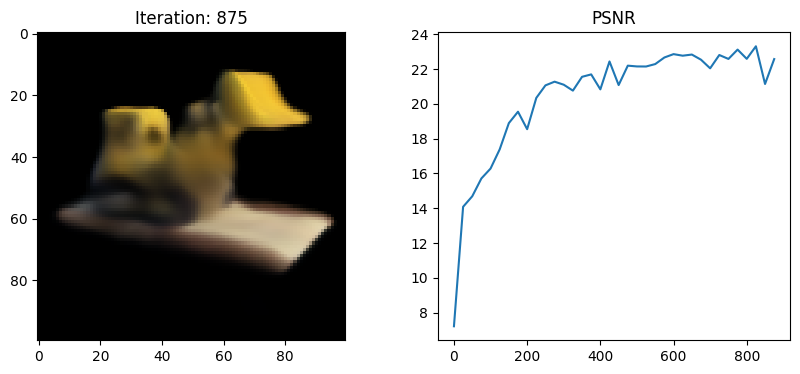

900 0.717167329788208 secs per iter


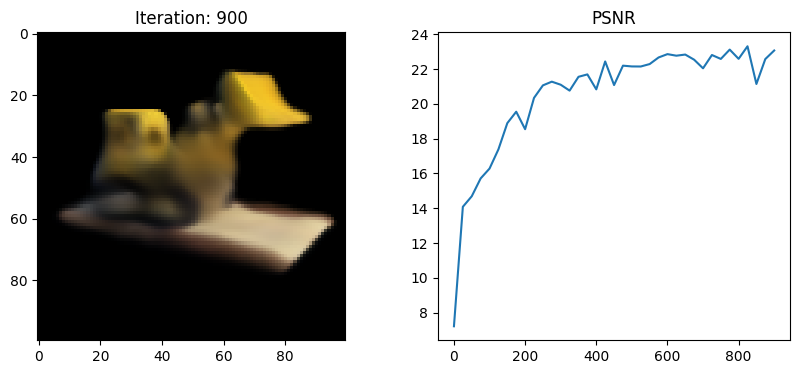

925 0.7215122413635254 secs per iter


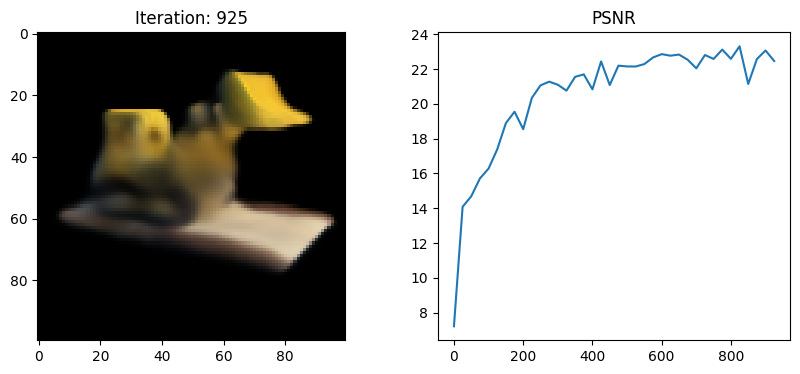

950 0.7085926914215088 secs per iter


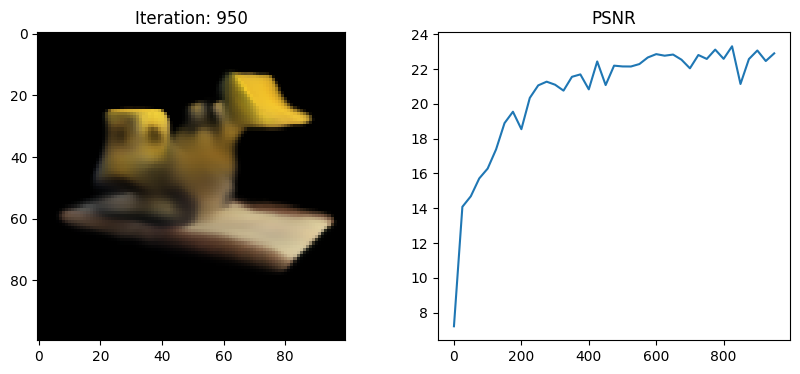

975 0.7128387451171875 secs per iter


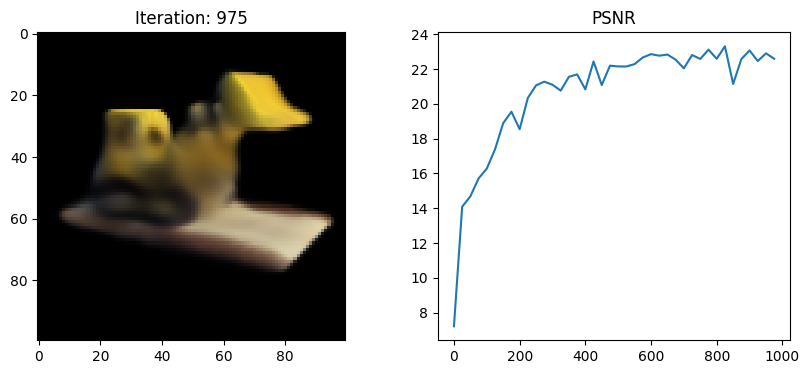

1000 0.7303048419952393 secs per iter


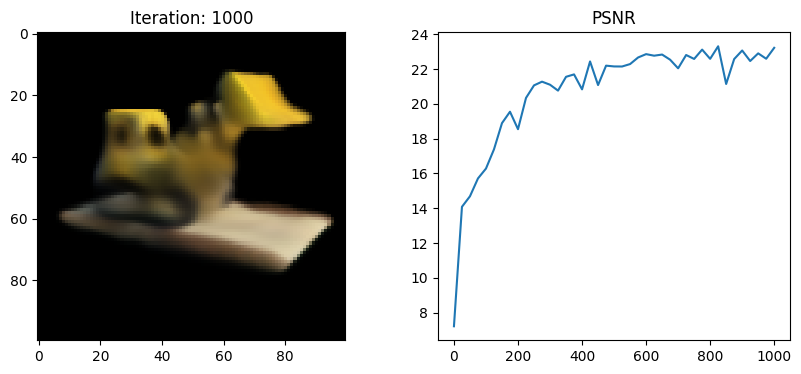

1025 0.714688777923584 secs per iter


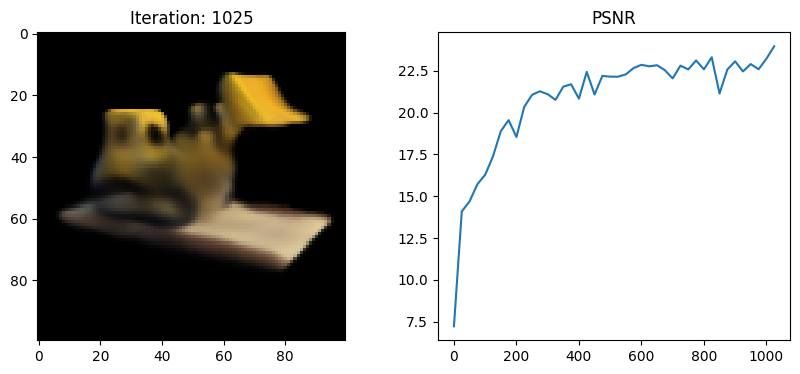

1050 0.7093796157836914 secs per iter


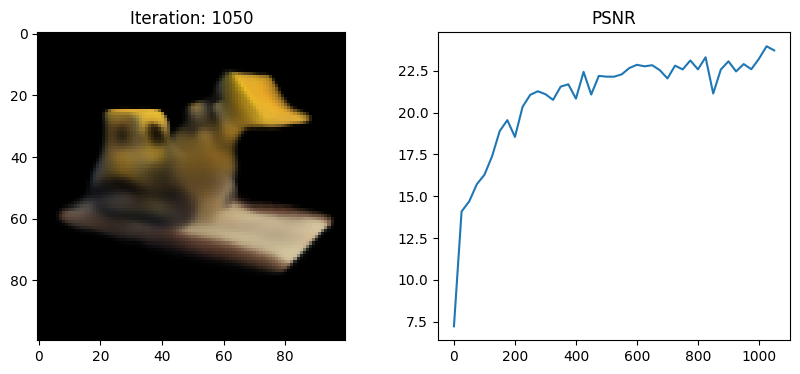

1075 0.7372925949096679 secs per iter


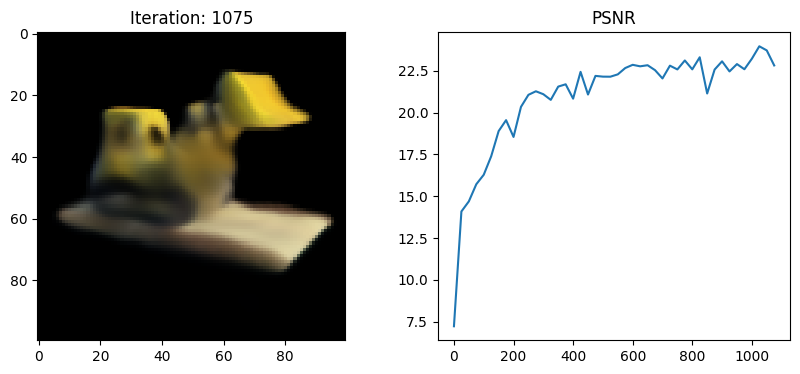

1100 0.7055426406860351 secs per iter


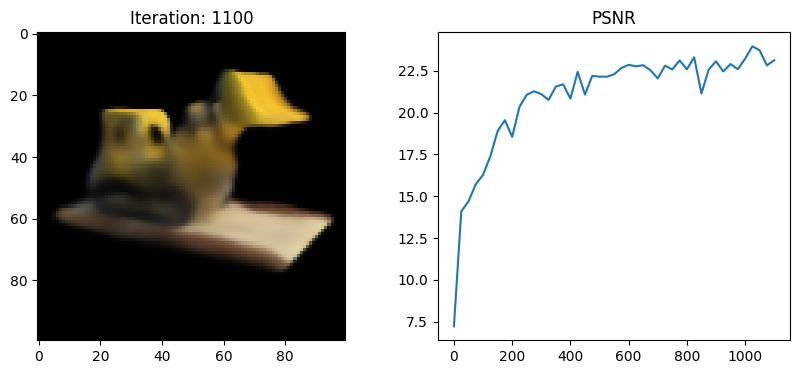

1125 0.7107117080688476 secs per iter


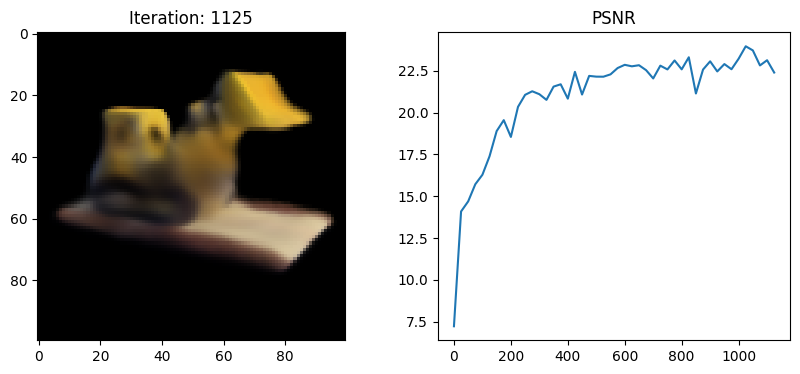

1150 0.7280537986755371 secs per iter


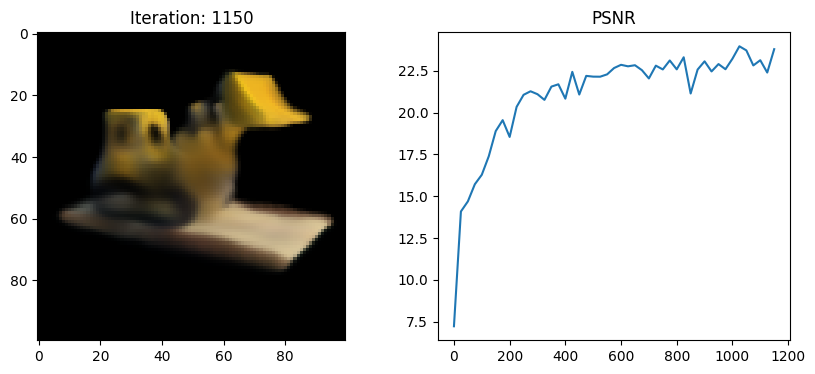

1175 0.71037109375 secs per iter


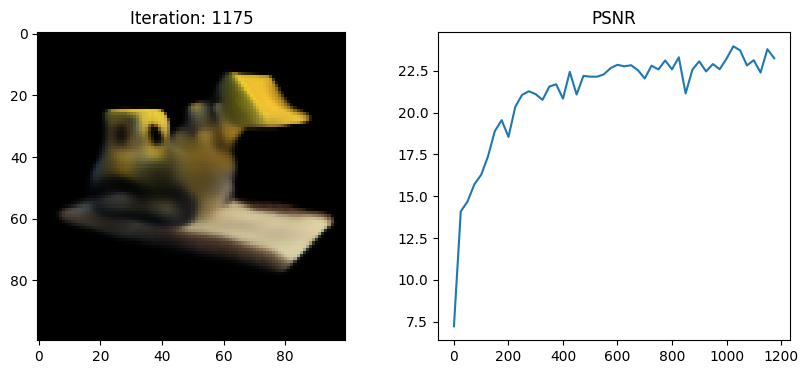

1200 0.7133468914031983 secs per iter


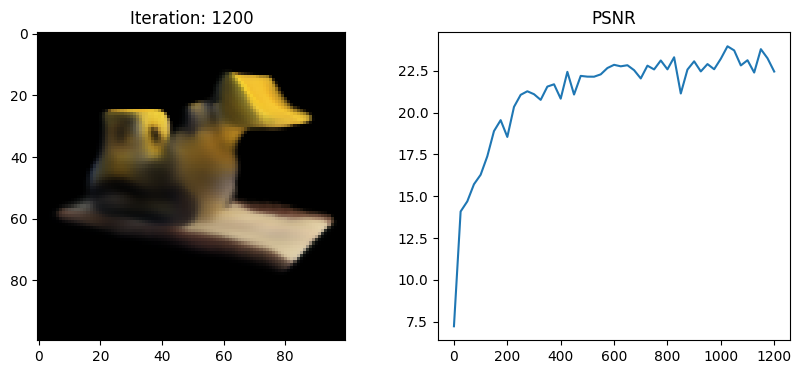

1225 0.7259203720092774 secs per iter


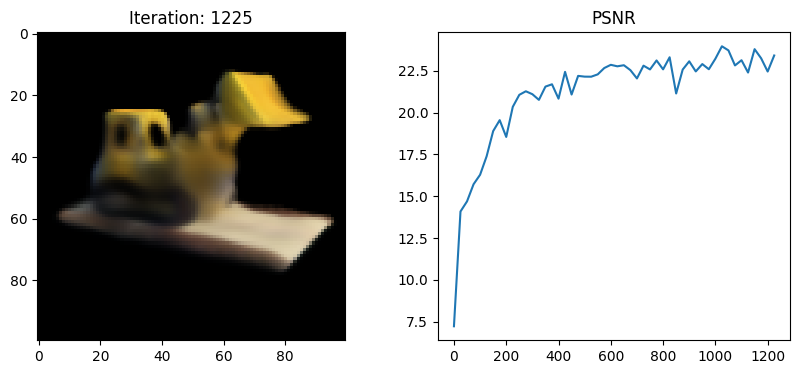

1250 0.7106558513641358 secs per iter


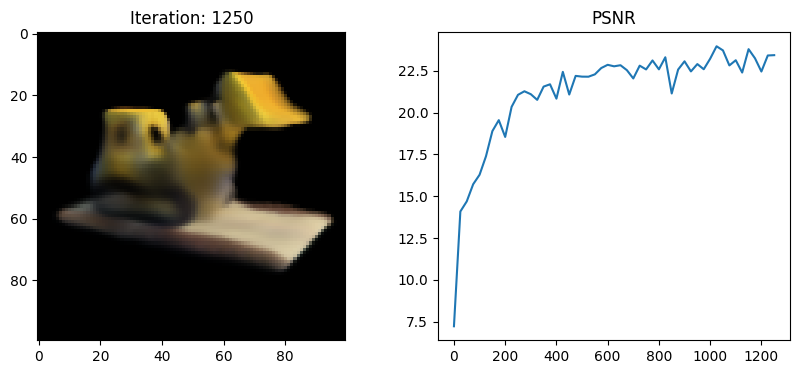

1275 0.7137902545928955 secs per iter


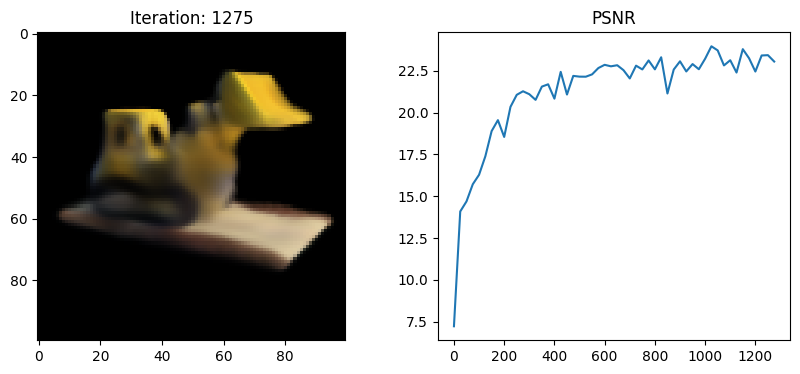

1300 0.7224131870269775 secs per iter


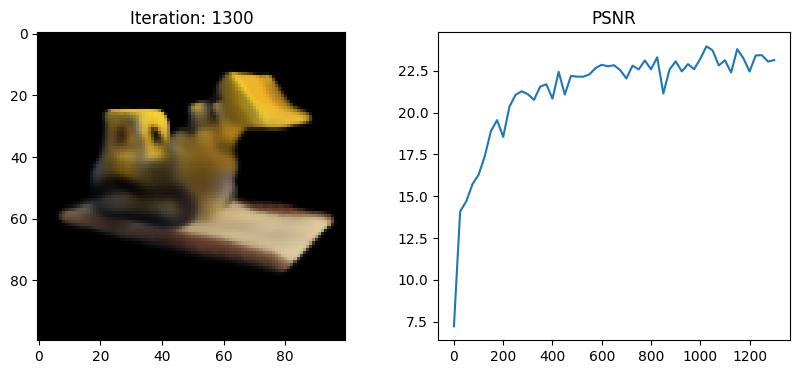

1325 0.7189618110656738 secs per iter


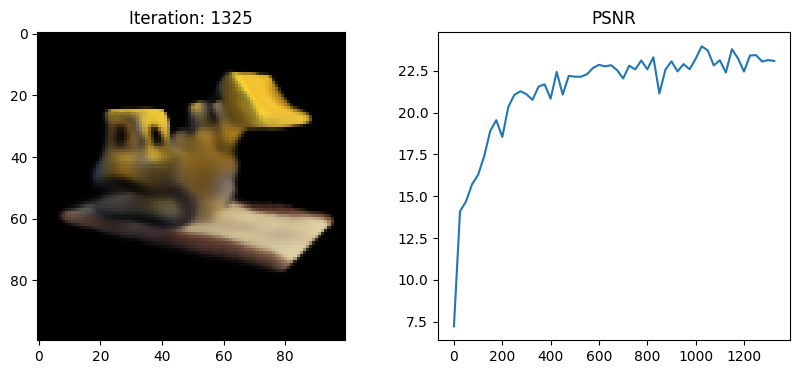

1350 0.7116192722320557 secs per iter


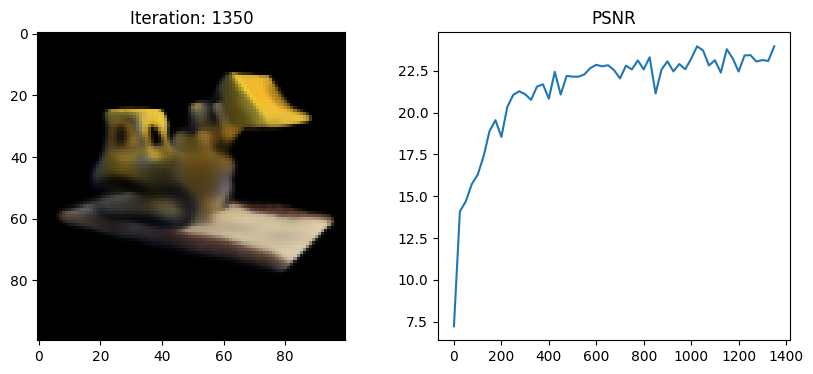

1375 0.7432539653778076 secs per iter


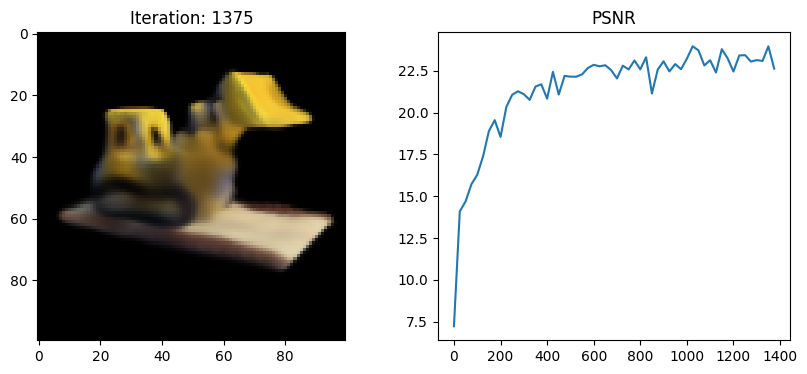

1400 0.7149903202056884 secs per iter


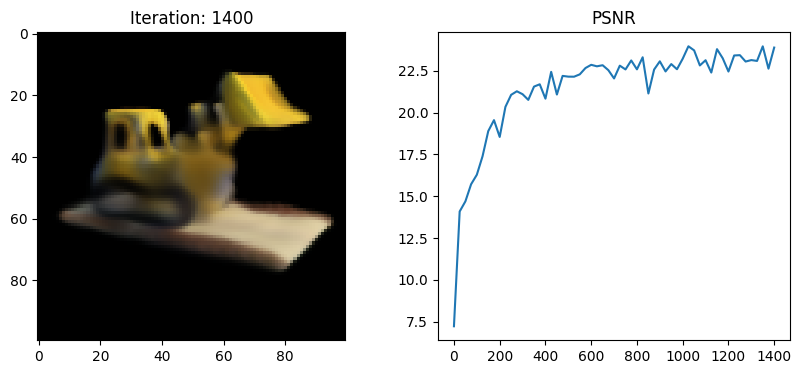

1425 0.7161587810516358 secs per iter


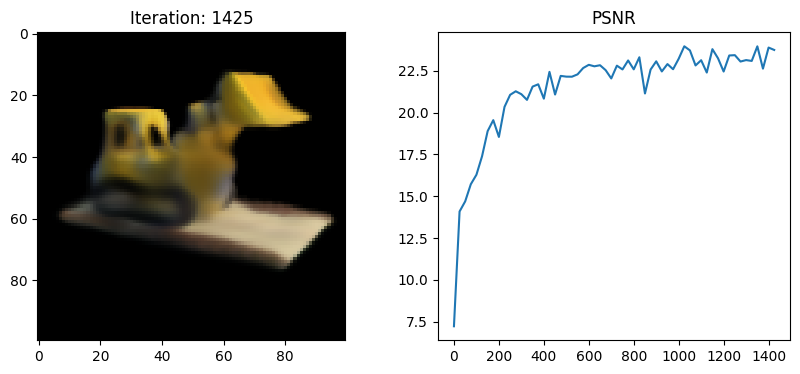

1450 0.7309468555450439 secs per iter


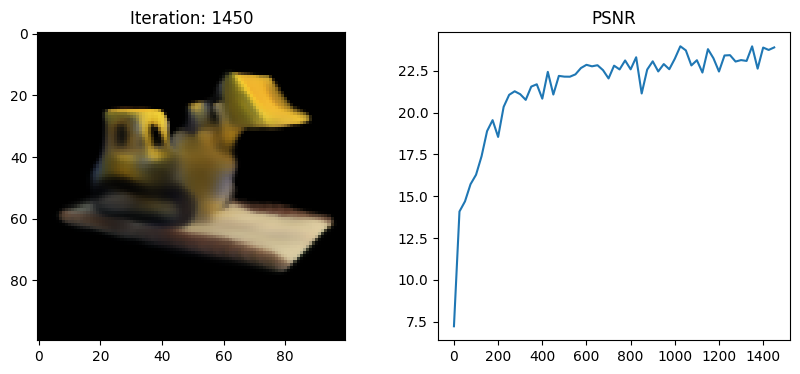

1475 0.7158053493499756 secs per iter


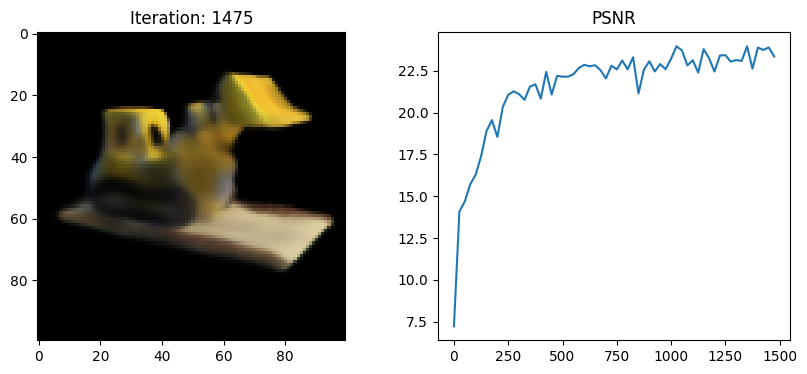

1500 0.7173724174499512 secs per iter


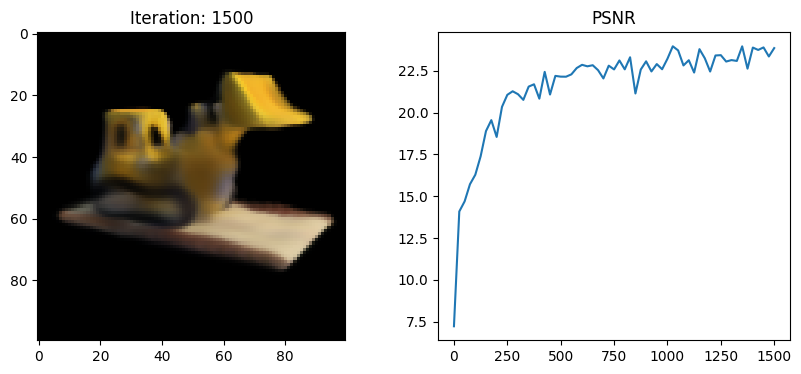

1525 0.7349236869812011 secs per iter


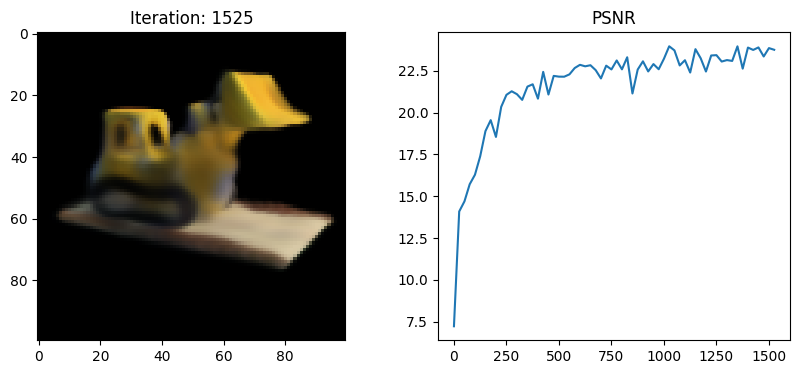

1550 0.7195570182800293 secs per iter


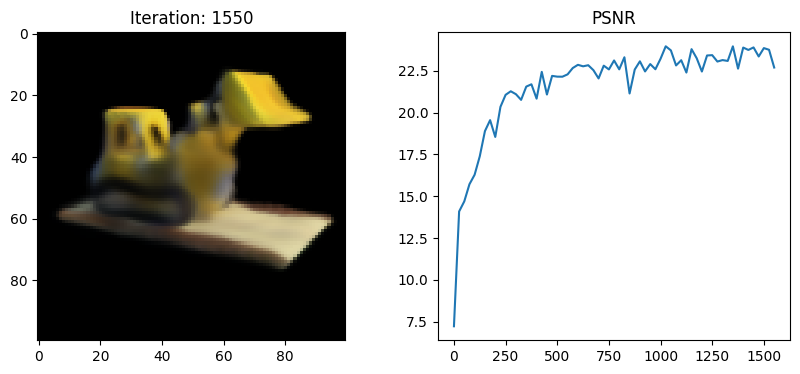

1575 0.7240496826171875 secs per iter


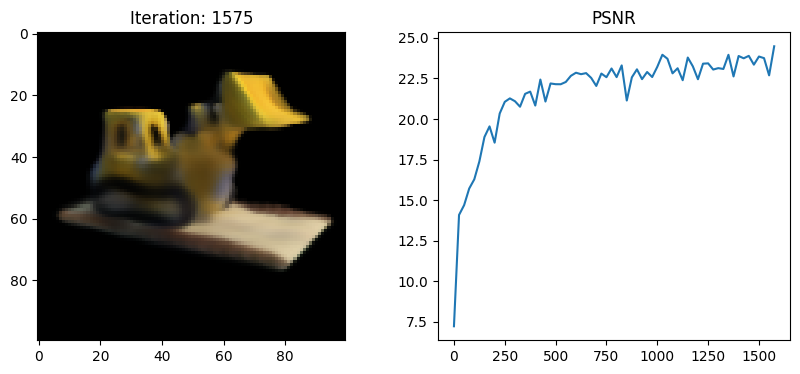

1600 0.7362669467926025 secs per iter


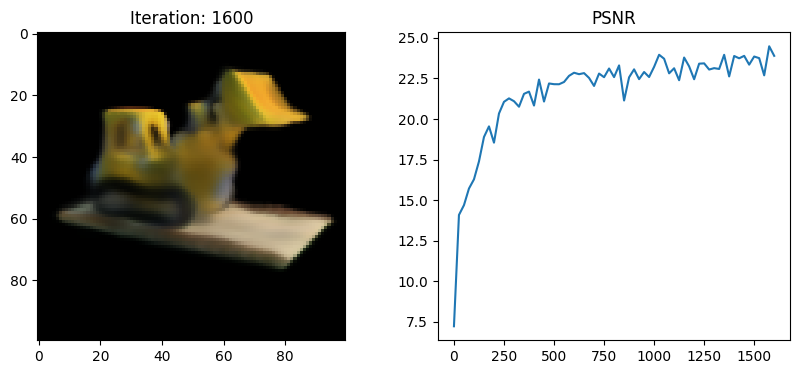

1625 0.7209218788146973 secs per iter


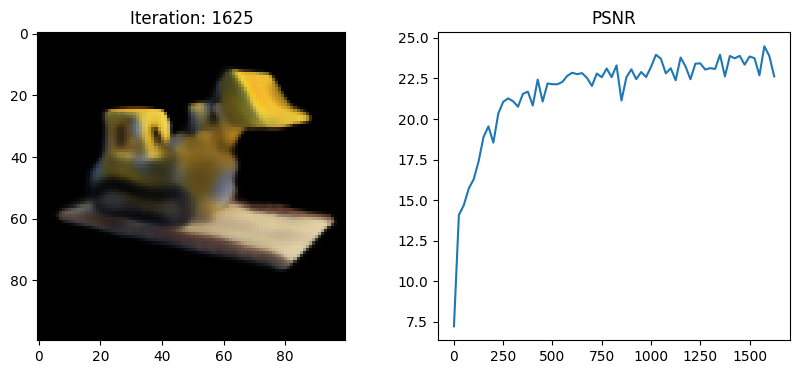

1650 0.7200870990753174 secs per iter


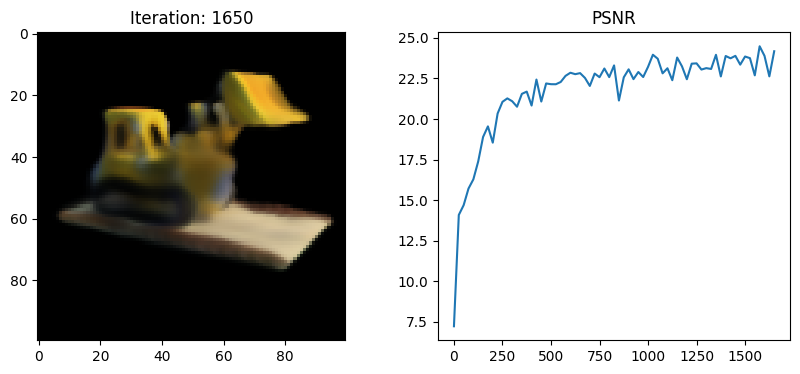

1675 0.751738634109497 secs per iter


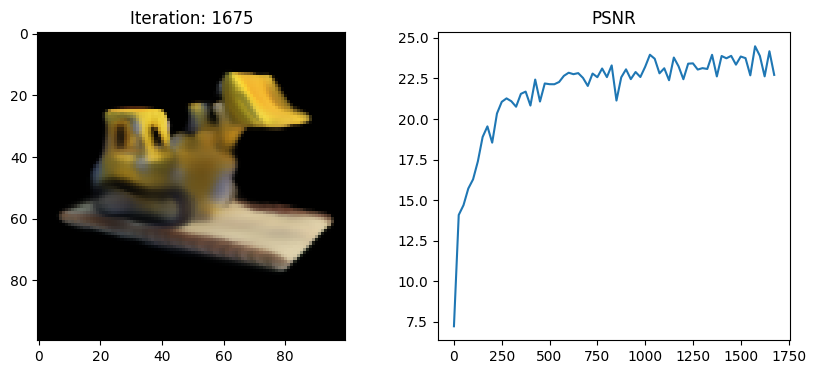

1700 0.7028531837463379 secs per iter


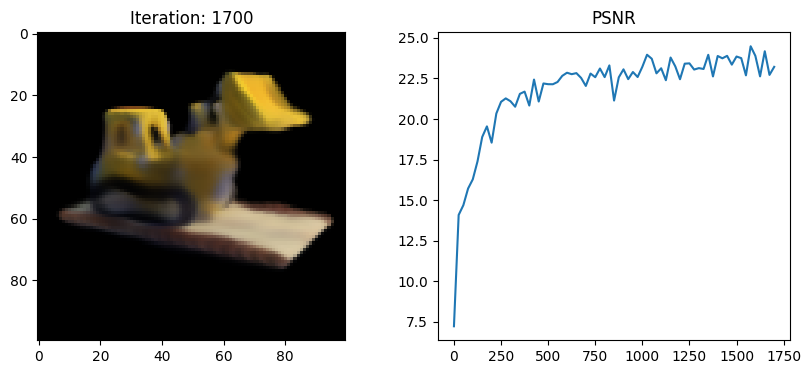

1725 0.7020502662658692 secs per iter


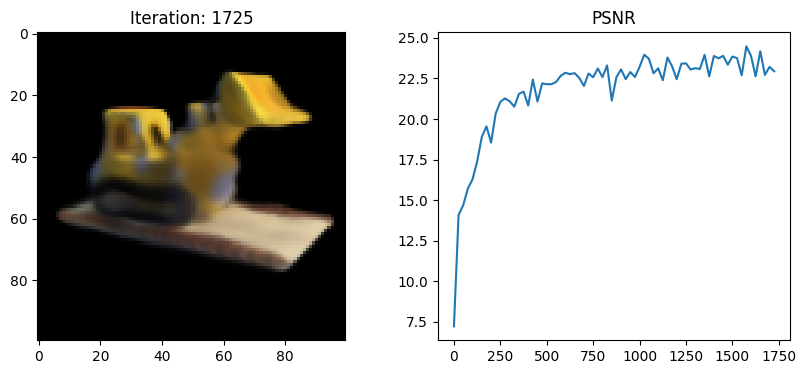

1750 0.7192038917541503 secs per iter


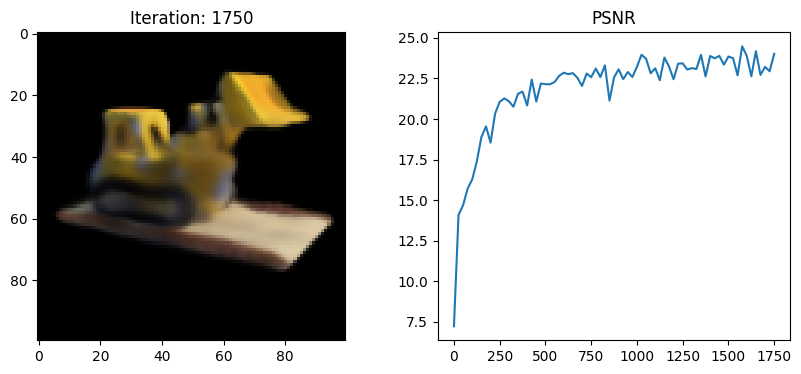

1775 0.701509370803833 secs per iter


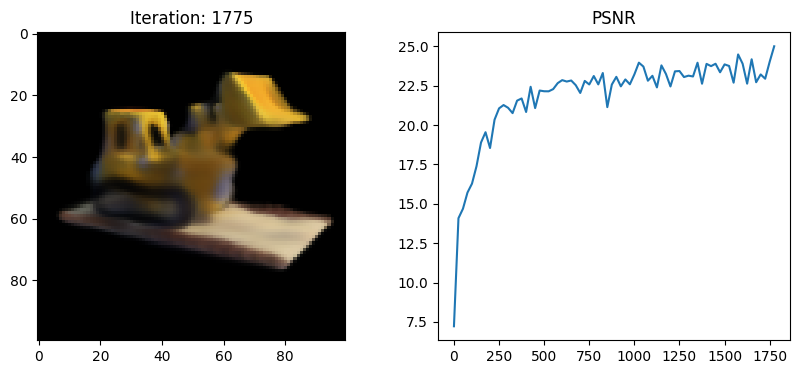

1800 0.7043392848968506 secs per iter


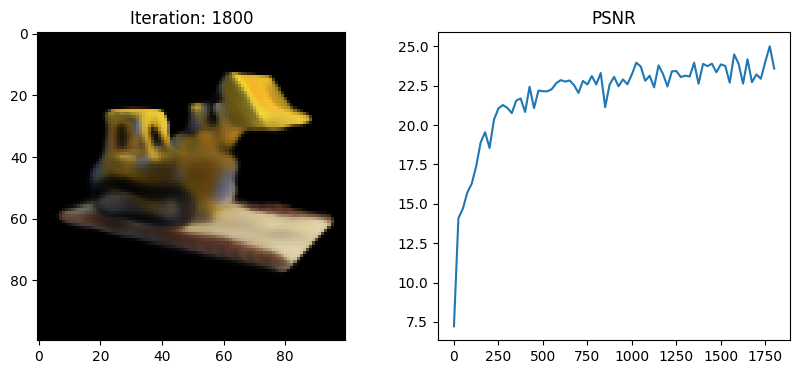

1825 0.7171236801147461 secs per iter


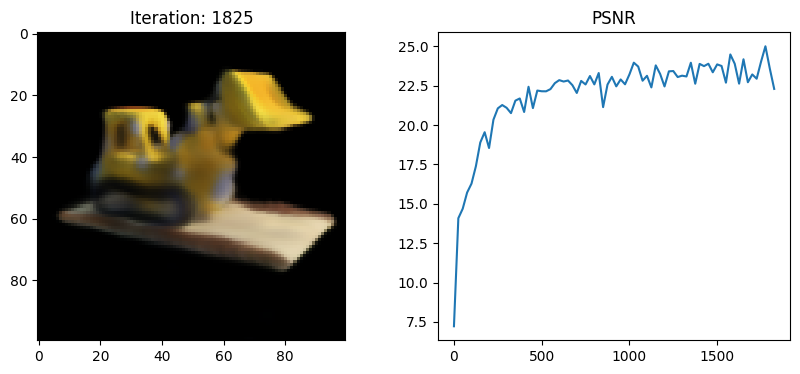

1850 0.7199994277954102 secs per iter


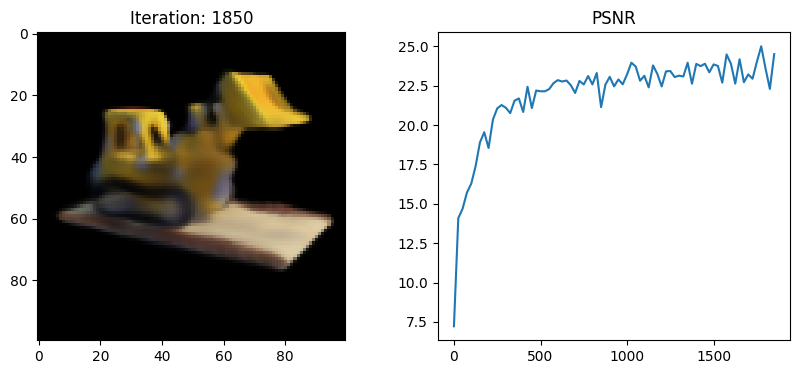

1875 0.711536569595337 secs per iter


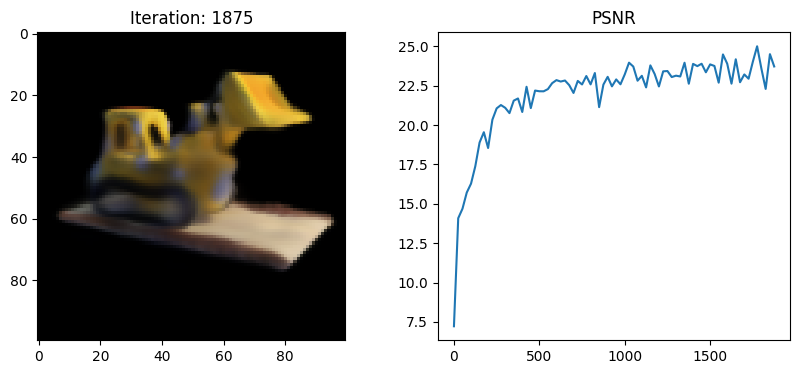

1900 0.7190258979797364 secs per iter


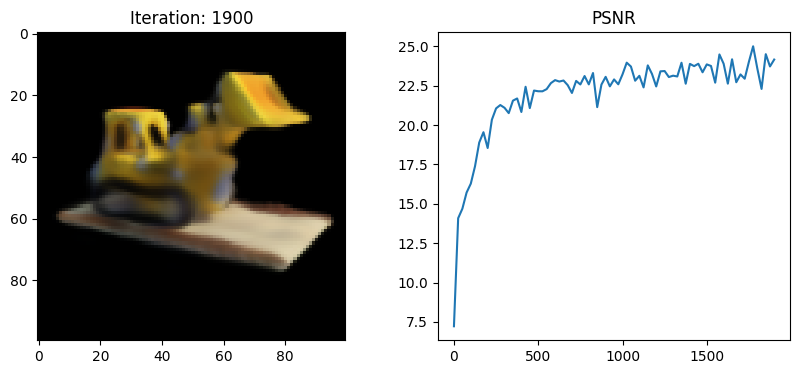

1925 0.7231504917144775 secs per iter


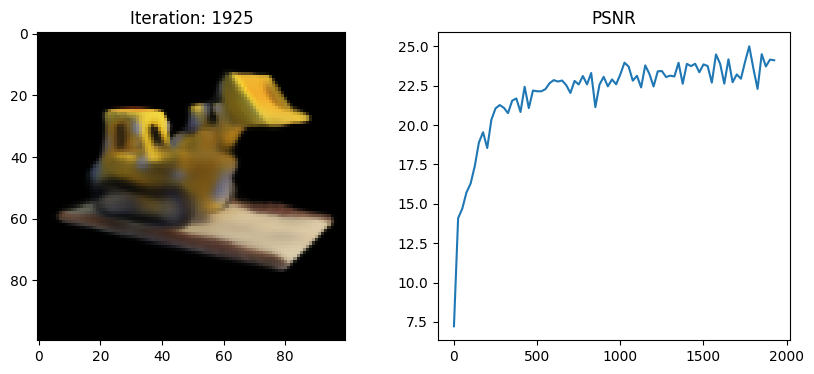

1950 0.7120812129974365 secs per iter


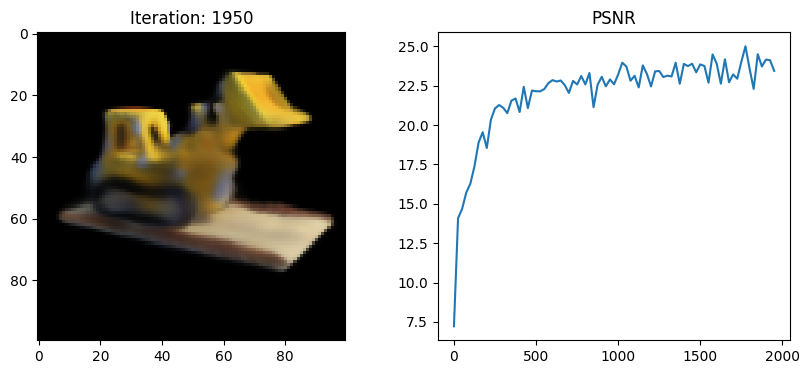

1975 0.7226001167297363 secs per iter


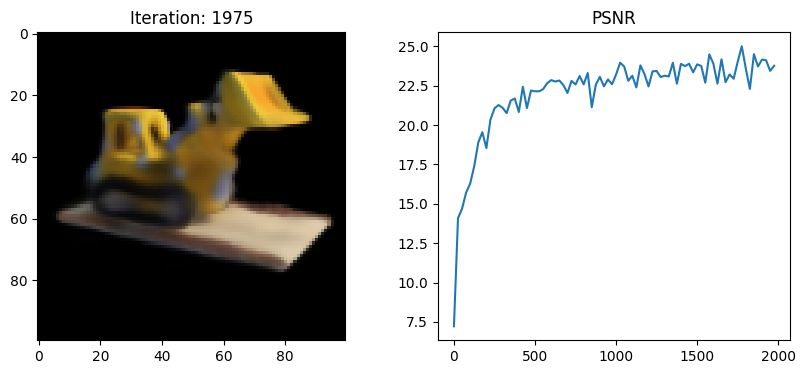

2000 0.7305448341369629 secs per iter


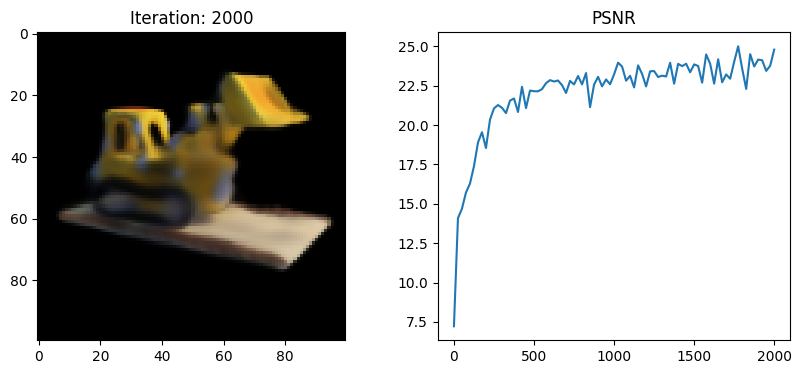

Final MSE: 0.00331595609895885
Final PSNR: 24.79391098022461 dB
Done


In [ ]:
model = init_model()
optimizer = tf.keras.optimizers.Adam(5e-4)
import time
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

N_samples = 64
N_iters = 2000
psnrs = []
mse_values = []  # List to store MSE values
iternums = []
i_plot = 25

t = time.time()
for i in range(N_iters + 1):
    img_i = np.random.randint(images.shape[0])
    target = images[img_i]
    pose = poses[img_i]
    rays_o, rays_d = get_rays(H, W, focal, pose)

    with tf.GradientTape() as tape:
        rgb, depth, acc = render_rays(model, rays_o, rays_d, near=2., far=6., N_samples=N_samples, rand=True)
        loss = tf.reduce_mean(tf.square(rgb - target))  # MSE calculation

    gradients = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))

    if i % i_plot == 0:
        print(i, (time.time() - t) / i_plot, 'secs per iter')
        t = time.time()

        # Evaluate on holdout (test) view
        rays_o, rays_d = get_rays(H, W, focal, testpose)
        rgb, depth, acc = render_rays(model, rays_o, rays_d, near=2., far=6., N_samples=N_samples)
        loss = tf.reduce_mean(tf.square(rgb - testimg))  # Compute MSE for test image
        psnr = -10. * tf.math.log(loss) / tf.math.log(10.)  # Compute PSNR

        psnrs.append(psnr.numpy())
        mse_values.append(loss.numpy())  # Store MSE value
        iternums.append(i)

        # Plot results
        plt.figure(figsize=(10, 4))
        plt.subplot(121)
        plt.imshow(rgb)
        plt.title(f'Iteration: {i}')
        plt.subplot(122)
        plt.plot(iternums, psnrs)
        plt.title('PSNR')
        plt.show()

# Print final MSE and PSNR values after training
final_mse = mse_values[-1] if mse_values else None
final_psnr = psnrs[-1] if psnrs else None

print(f"Final MSE: {final_mse}")
print(f"Final PSNR: {final_psnr} dB")

print('Done')


### **Interactive Visualization of the 3D Scene**

This step involves creating an interactive visualization where the camera view (theta, phi, and radius) can be adjusted in real-time to observe how the 3D scene changes.

In [ ]:
%matplotlib inline
from ipywidgets import interactive, widgets
trans_t = lambda t : tf.convert_to_tensor([
    [1,0,0,0],
    [0,1,0,0],
    [0,0,1,t],
    [0,0,0,1],
], dtype=tf.float32)


rot_phi = lambda phi : tf.convert_to_tensor([
    [1,0,0,0],
    [0,tf.cos(phi),-tf.sin(phi),0],
    [0,tf.sin(phi), tf.cos(phi),0],
    [0,0,0,1],
], dtype=tf.float32)

rot_theta = lambda th : tf.convert_to_tensor([
    [tf.cos(th),0,-tf.sin(th),0],
    [0,1,0,0],
    [tf.sin(th),0, tf.cos(th),0],
    [0,0,0,1],
], dtype=tf.float32)


def pose_spherical(theta, phi, radius):
    c2w = trans_t(radius)
    c2w = rot_phi(phi/180.*np.pi) @ c2w
    c2w = rot_theta(theta/180.*np.pi) @ c2w
    c2w = np.array([[-1,0,0,0],[0,0,1,0],[0,1,0,0],[0,0,0,1]]) @ c2w
    return c2w


def f(**kwargs):
    c2w = pose_spherical(**kwargs)
    rays_o, rays_d = get_rays(H, W, focal, c2w[:3,:4])
    rgb, depth, acc = render_rays(model, rays_o, rays_d, near=2., far=6., N_samples=N_samples)
    img = np.clip(rgb,0,1)

    plt.figure(2, figsize=(20,6))
    plt.imshow(img)
    plt.show()


sldr = lambda v, mi, ma: widgets.FloatSlider(
    value=v,
    min=mi,
    max=ma,
    step=.01,
)

names = [
    ['theta', [100., 0., 360]],
    ['phi', [-30., -90, 0]],
    ['radius', [4., 3., 5.]],
]

interactive_plot = interactive(f, **{s[0] : sldr(*s[1]) for s in names})
output = interactive_plot.children[-1]
output.layout.height = '350px'
interactive_plot

interactive(children=(FloatSlider(value=100.0, description='theta', max=360.0, step=0.01), FloatSlider(value=-…

In [ ]:
frames = []
for th in tqdm(np.linspace(0., 360., 120, endpoint=False)):
    c2w = pose_spherical(th, -30., 4.)
    rays_o, rays_d = get_rays(H, W, focal, c2w[:3,:4])
    rgb, depth, acc = render_rays(model, rays_o, rays_d, near=2., far=6., N_samples=N_samples)
    frames.append((255*np.clip(rgb,0,1)).astype(np.uint8))

import imageio
f = 'video.mp4'
imageio.mimwrite(f, frames, fps=30, quality=7)

<ipython-input-11-bc28ed268829>:2: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for th in tqdm(np.linspace(0., 360., 120, endpoint=False)):


  0%|          | 0/120 [00:00<?, ?it/s]

In [ ]:
from IPython.display import HTML
from base64 import b64encode
mp4 = open('video.mp4','rb').read()
data_url = "data:video/mp4;base64," + b64encode(mp4).decode()
HTML("""
<video width=400 controls autoplay loop>
      <source src="%s" type="video/mp4">
</video>
""" % data_url)

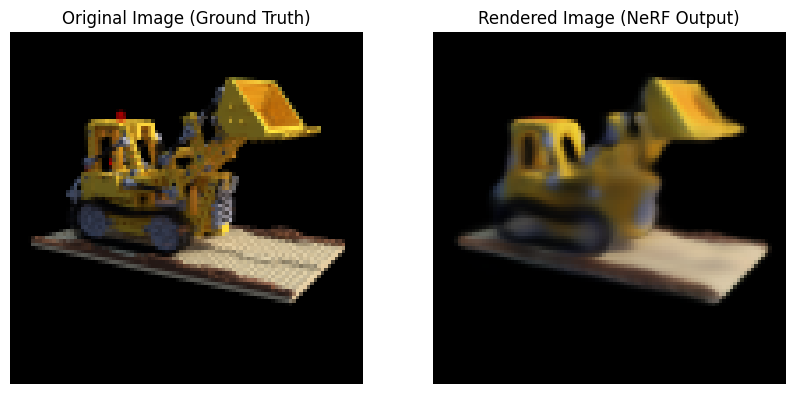

In [ ]:
import matplotlib.pyplot as plt

# Select an image index for visualization
img_idx = 10  # Change index as needed

# Original Image (Ground Truth)
original_img = images[img_idx]

# Rendered Image after Training
pose = poses[img_idx]
rays_o, rays_d = get_rays(H, W, focal, pose)
rendered_img, _, _ = render_rays(model, rays_o, rays_d, near=2., far=6., N_samples=N_samples)

# Plot Comparison
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(original_img)
plt.title("Original Image (Ground Truth)")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(rendered_img)
plt.title("Rendered Image (NeRF Output)")
plt.axis("off")

plt.show()
